TokaMaker Meshing Example: Building a mesh for ARC V3A {#doc_tMaker_ARC_ex1}
==========
This is based on the ARC V3A digital assets as described in Appendix A of Hillesheim et al, "Overview of the physics basis for the ARC fusion power plant" Journal of Plasma Physics (2026).  https://doi.org/10.1017/S0022377826101706

All files available on Zenodo at: https://zenodo.org/records/19498373

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the PYTHONPATH environment variable or using within a script using sys.path.append() as below, where we look for the environement variable OFT_ROOTPATH to provide the path to where the OpenFUSIONToolkit is installed (/Applications/OFT on macOS).

For meshing we will use the gs_Domain class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the triangle code through a python wrapper.

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh

## Load geometry information
The geometry information (e.g. bounding curves for vacuum vessels) is loaded from a JSON file available on [Zenodo](https://zenodo.org/records/19498373). The cell below downloads the file automatically if it is not already present locally.

The JSON contains:
- `limiter`: R,Z contour of the limiter (PFC) surface
- `inner_vv` / `outer_vv`: inner and outer boundary contours of each vacuum vessel
- `coils`: dictionary of PF coil filament elements


In [3]:
import urllib.request

_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

_fetch('device_V3A.json')

with open('device_V3A.json') as f:
    mach = json.load(f)


## Define coil array

Each coil's bounding rectangle is derived directly from the filament grid in the device JSON. The center is the midpoint of all filament positions, and the width/height extend by half a grid pitch beyond the outermost filaments in each direction to match the physical winding pack boundary.

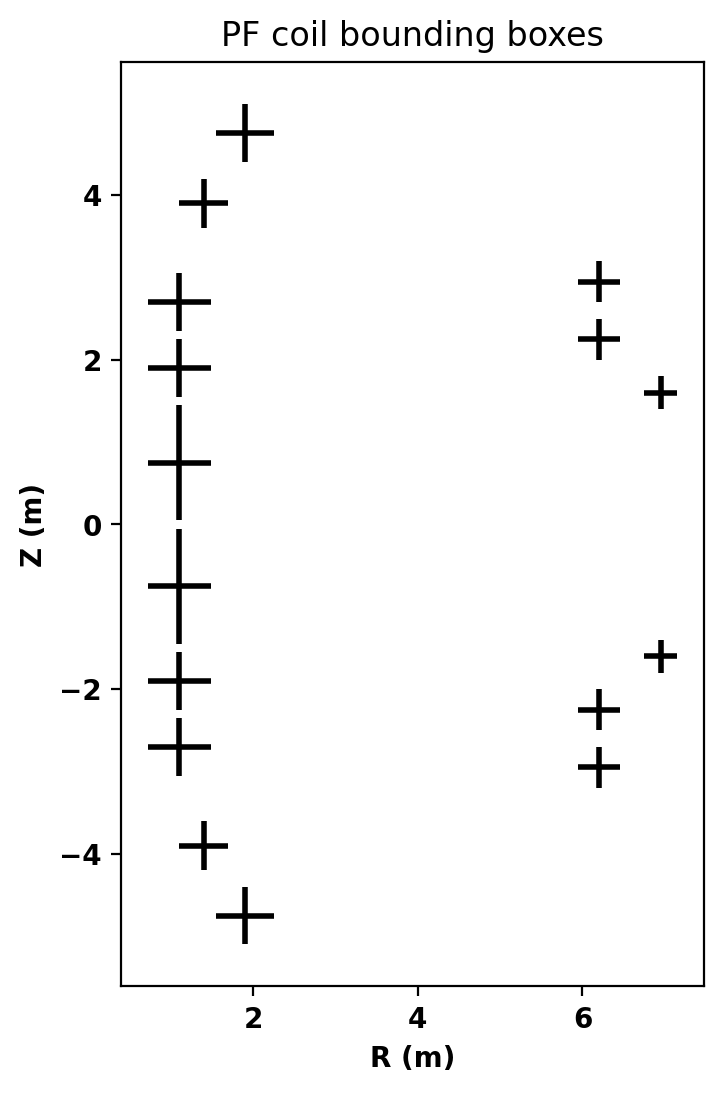

cs1u      r=1.1050  z=+0.7500  dr=0.7700  dz=1.4000  n=1150
cs1l      r=1.1050  z=-0.7500  dr=0.7700  dz=1.4000  n=1150
cs2u      r=1.1050  z=+1.9000  dr=0.7700  dz=0.7000  n=575
cs2l      r=1.1050  z=-1.9000  dr=0.7700  dz=0.7000  n=575
cs3u      r=1.1050  z=+2.7000  dr=0.7700  dz=0.7000  n=575
cs3l      r=1.1050  z=-2.7000  dr=0.7700  dz=0.7000  n=575
pf1u      r=1.4000  z=+3.9000  dr=0.6000  dz=0.6000  n=400
pf1l      r=1.4000  z=-3.9000  dr=0.6000  dz=0.6000  n=400
pf2u      r=1.9000  z=+4.7500  dr=0.7000  dz=0.7000  n=529
pf2l      r=1.9000  z=-4.7500  dr=0.7000  dz=0.7000  n=529
pf3u      r=6.2000  z=+2.9500  dr=0.5000  dz=0.5000  n=256
pf3l      r=6.2000  z=-2.9500  dr=0.5000  dz=0.5000  n=256
pf4u      r=6.2000  z=+2.2500  dr=0.5000  dz=0.5000  n=256
pf4l      r=6.2000  z=-2.2500  dr=0.5000  dz=0.5000  n=256
pf5u      r=6.9500  z=+1.6000  dr=0.4000  dz=0.4000  n=169
pf5l      r=6.9500  z=-1.6000  dr=0.4000  dz=0.4000  n=169


In [4]:
def extract_coil_geometry(coil_elements):
    """Extract center (r, z), bounding box (dr, dz), and filament count from coil elements.

    Filaments sit on a regular grid; the coil boundary extends half a grid pitch
    beyond the outermost filament centers in each direction.
    """
    rs = np.array([el['geometry']['annulus']['r'] for el in coil_elements])
    zs = np.array([el['geometry']['annulus']['z'] for el in coil_elements])
    rs_unique = np.unique(np.round(rs, 6))
    zs_unique = np.unique(np.round(zs, 6))
    pitch_r = np.mean(np.diff(rs_unique)) if len(rs_unique) > 1 else 0.0
    pitch_z = np.mean(np.diff(zs_unique)) if len(zs_unique) > 1 else 0.0
    r  = 0.5 * (rs.max() + rs.min())
    z  = 0.5 * (zs.max() + zs.min())
    dr = (rs.max() - rs.min()) + pitch_r
    dz = (zs.max() - zs.min()) + pitch_z
    return r, z, dr, dz, len(coil_elements)


coil_data = {}
plt.figure()
for coil in mach['pf_active']['coil']:
    r, z, dr, dz, n = extract_coil_geometry(coil['element'])
    coil_data[coil['name']] = dict(r=r, z=z, dr=dr, dz=dz, n_filaments=n)
    plt.errorbar(r, z, xerr=dr/2, yerr=dz/2, c='k')

plt.gca().set_aspect('equal')
plt.xlabel('R (m)')
plt.ylabel('Z (m)')
plt.title('PF coil bounding boxes')
plt.show()

coil_name    = np.array(list(coil_data.keys()))
coil_r       = [round(coil_data[c]['r'],       4) for c in coil_name]
coil_z       = [round(coil_data[c]['z'],       4) for c in coil_name]
coil_dr      = [round(coil_data[c]['dr'],      4) for c in coil_name]
coil_dz      = [round(coil_data[c]['dz'],      4) for c in coil_name]
coil_nturns  = [coil_data[c]['n_filaments']        for c in coil_name]

for name, r, z, dr, dz, n in zip(coil_name, coil_r, coil_z, coil_dr, coil_dz, coil_nturns):
    print(f'{name:<8}  r={r:.4f}  z={z:+.4f}  dr={dr:.4f}  dz={dz:.4f}  n={n}')


Here we check the resistivity of each element in the json, printing the results to the notebook.

In [5]:
for element in mach['wall']['description_2d']:
    print(element['type'])
    if 'vessel' in element.keys():
        print(f"{len(element['vessel']['unit'])} items:")
        for item in element['vessel']['unit']:
            try:
                print(' -- ', item['annular'].keys())
                print('    ', 'Resistivity:', item['annular']['resistivity'])
            except KeyError:
                print(' -- ', item['element'][0]['name'])
                print('    ', 'Resistivity:', item['element'][0]['resistivity'])
                

{'description': 'Single limiter surface', 'index': 0}
{'description': 'Annular description of vessel', 'index': 2}
3 items:
 --  dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 9e-07
 --  dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 6e-07
 --  dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 6e-07
{'description': 'Annular description of blanket', 'index': 5}
1 items:
 --  dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 7.4e-07
{'description': 'Block description of shield', 'index': 6}
1 items:
 --  Shield
     Resistivity: 2e-07


# Set mesh resolution for each region

First we define some target sizes to set the resolution in out grid. These variables will be used later and represent the target edge size within a given region, where units are in meters. In this case we are using a fairly coarse resolution for speed, but you can increase it for fidelity if needed.

In [6]:
plasma_res  = 0.2   # target edge length inside the plasma (m)
coil_res    = 0.1   # PF coil regions
vv_res      = 0.05  # vacuum vessel walls
vac_res     = 0.2   # vacuum / air regions
blanket_res = 0.1   # blanket
FLIBE_res   = 0.1   # FLiBe (only used if include_FLIBE = True)

shield_resistivity = mach['wall']['description_2d'][3]['vessel']['unit'][0]['element'][0]['resistivity']


## Define regions and attributes
We now create and define the various logical mesh regions. In the SPARC case we have 6 regions:

- `air`: The region outside the vacuum vessel, which is not actually air in a superconducting device like ARC but we use this terminology for commonality with present research devices
- `plasma:` The region inside the limiter where the plasma will exist
- `vessel_inner`: The inner vacuum vessel
- `vessel_outer`: The outer vacuum vessel
- `blanket`: (recommended) The conducting region surrounding the blanket
- `flibe`: (optional) If activate, will include a special FLiBe region. Otherwise, fill this region with air.
- `coil`: The coils

In [7]:
gs_mesh = gs_Domain()

# Vacuum and plasma
gs_mesh.define_region('air',     vac_res,    'boundary')  # outer bounding box
gs_mesh.define_region('air_out', vac_res,    'boundary')  # region between VV and coils
gs_mesh.define_region('plasma',  plasma_res, 'plasma')

# Vacuum vessel walls (inner and outer)
gs_mesh.define_region('vessel_inner', vv_res, 'conductor', mach['wall']['description_2d'][1]['vessel']['unit'][1]['annular']['resistivity'], allow_xpoints=True)
gs_mesh.define_region('vessel_outer', vv_res, 'conductor', mach['wall']['description_2d'][1]['vessel']['unit'][2]['annular']['resistivity'], allow_xpoints=True)

# Typically you don't want to include the shield in the mesh
include_shield = False
if include_shield:
    gs_mesh.define_region('shield', vv_res, 'conductor', shield_resistivity, allow_xpoints=True)

# Blanket
for i in np.arange(len(mach['wall']['description_2d'])):
    if mach['wall']['description_2d'][i]['type']['index'] == 5:
        i_blanket = i
gs_mesh.define_region('blanket', blanket_res, 'conductor', mach['wall']['description_2d'][i_blanket]['vessel']['unit'][0]['annular']['resistivity'], allow_xpoints=True)

# Typically you don't want to include the FLIBE in the mesh
include_FLIBE = False
if include_FLIBE:
    gs_mesh.define_region('flibe', FLIBE_res, 'conductor', 0.005, allow_xpoints=True)

# PF coils — nTurns set to the filament count extracted from the device JSON
for i in range(16):
    gs_mesh.define_region(coil_name[i], coil_res, 'coil', nTurns=coil_nturns[i])


## Define geometry for region boundaries

Once the region types and properties are defined we now define the geometry of the mesh using shapes and references to the defined regions.

In [8]:
vv_units = mach['wall']['description_2d'][1]['vessel']['unit']

# Inner vacuum vessel
vv_inner_inner = np.column_stack((vv_units[1]['annular']['outline_inner']['r'], 
                                  np.array(vv_units[1]['annular']['outline_inner']['z'])))
vv_inner_outer = np.column_stack((vv_units[1]['annular']['outline_outer']['r'], 
                                  np.array(vv_units[1]['annular']['outline_outer']['z'])))
gs_mesh.add_annulus(vv_inner_inner,'plasma',vv_inner_outer,'vessel_inner')

# Outer vacuum vessel
vv_outer_inner = np.column_stack((vv_units[2]['annular']['outline_inner']['r'], 
                                  np.array(vv_units[2]['annular']['outline_inner']['z'])))
vv_outer_outer = np.column_stack((vv_units[2]['annular']['outline_outer']['r'], 
                                  np.array(vv_units[2]['annular']['outline_outer']['z'])))
gs_mesh.add_annulus(vv_outer_inner,'air',vv_outer_outer,'vessel_outer')

# Blanket
bl_inner = np.column_stack((mach['wall']['description_2d'][i_blanket]['vessel']['unit'][0]['annular']['outline_inner']['r'], 
                            np.array(mach['wall']['description_2d'][i_blanket]['vessel']['unit'][0]['annular']['outline_inner']['z'])))
bl_outer = np.column_stack((mach['wall']['description_2d'][i_blanket]['vessel']['unit'][0]['annular']['outline_outer']['r'], 
                            np.array(mach['wall']['description_2d'][i_blanket]['vessel']['unit'][0]['annular']['outline_outer']['z'])))

if include_FLIBE:
    gs_mesh.add_annulus(bl_inner,'flibe',bl_outer,'blanket')
else:
    gs_mesh.add_annulus(bl_inner,'air',bl_outer,'blanket',parent_name='air_out')

# Shield (optional)
if include_shield:
    shield_r = mach['wall']['description_2d'][3]['vessel']['unit'][0]['element'][0]['outline']['r']
    shield_z = mach['wall']['description_2d'][3]['vessel']['unit'][0]['element'][0]['outline']['z']
    shield_contour = np.column_stack((np.hstack([shield_r, shield_r[0]]),np.hstack([shield_z, shield_z[0]])))
    gs_mesh.add_polygon(shield_contour, 'shield', parent_name='air')

# PF coils — rectangles sized from the extracted bounding boxes
for i in range(16):
    gs_mesh.add_rectangle(coil_r[i], coil_z[i], coil_dr[i], coil_dz[i], coil_name[i],parent_name='air_out')


## Plot topology

After defining the logical and physical topology we can now plot the curves within the definitions to double check everything is in the right place. In cases where curves appear to cross eachother (as with the VS coil and inner VV) one should zoom in to ensure no crossings exist. In this case we had to move the upper VS coil down by 1 cm to avoid an intersection with the geometry available for this example.

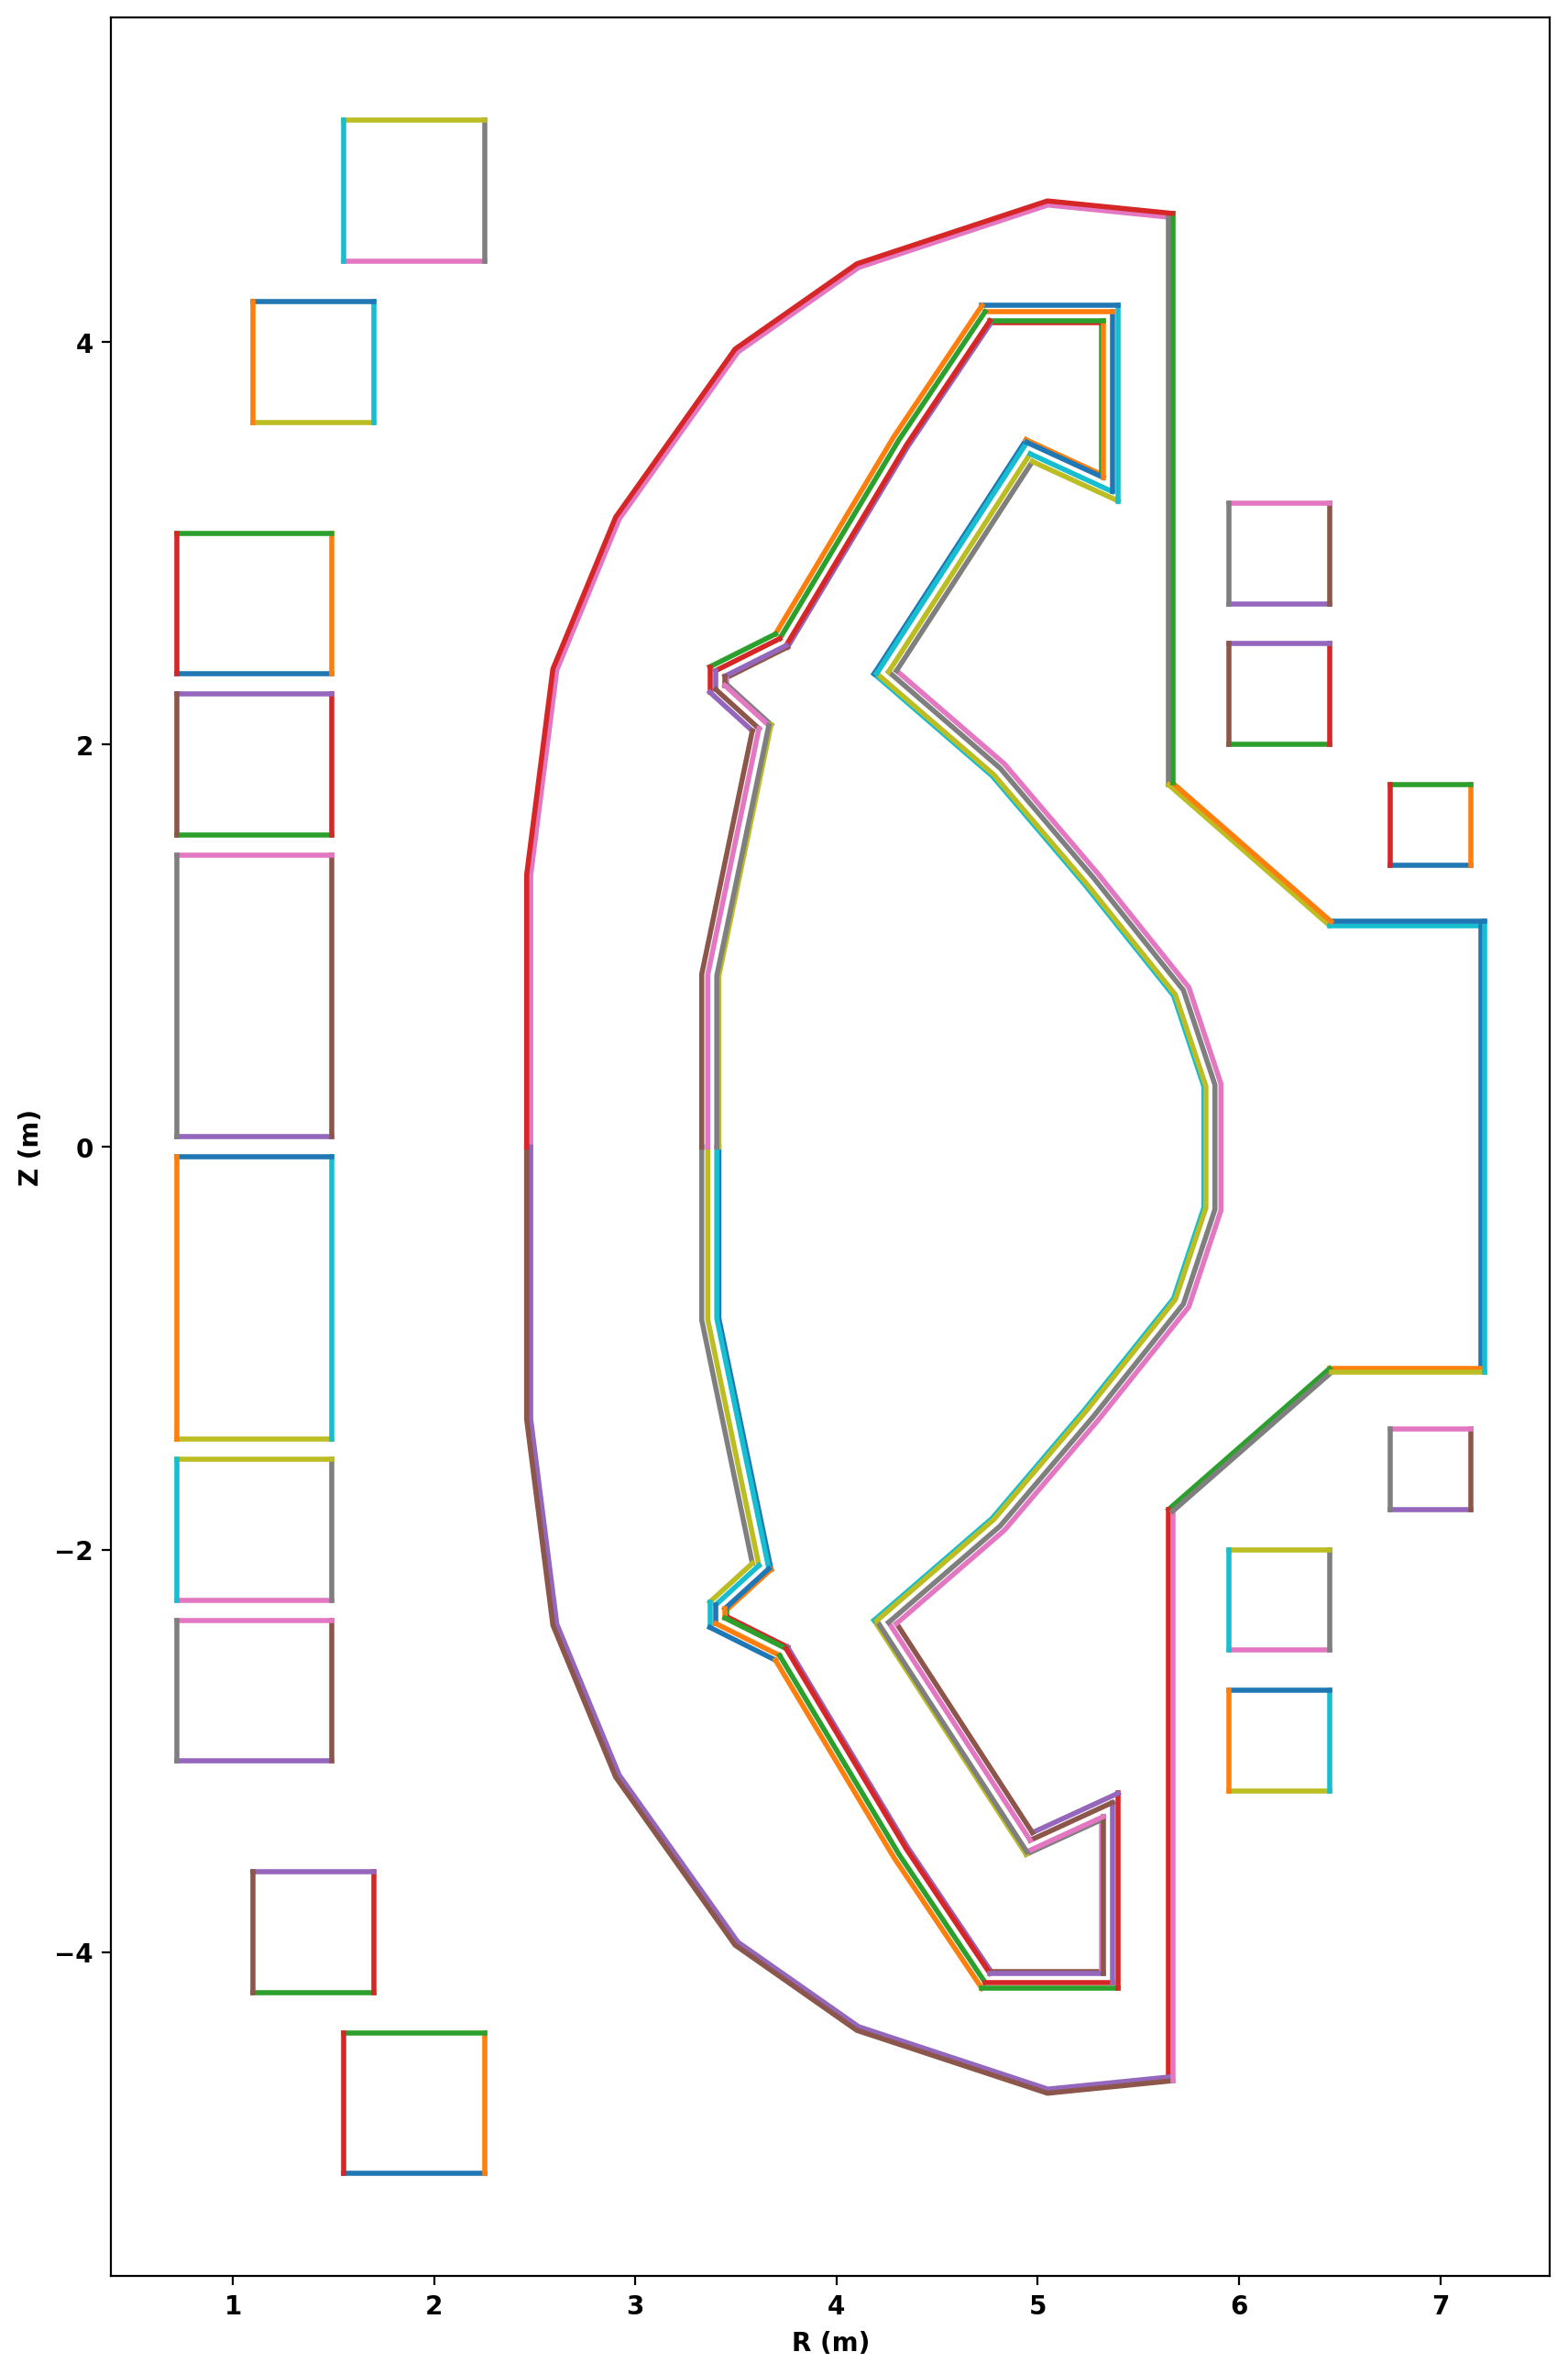

In [9]:
fig, ax = plt.subplots(1,1, figsize=(20,16))
gs_mesh.plot_topology(fig,ax)

## Create mesh

Now we generate the actual mesh using the `build_mesh` method. Additionally, since coil and conductor regions are defined, the `get_coils` and `get_conductors` methods should also be called to get descriptive dictionaries for later use in TokaMaker. This step may take a few moments as triangle generates the mesh.

In [10]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Assembling regions:
  # of unique points    = 2800
  # of unique segments  = 162
Generating mesh with Triangle:
  # of points  = 9281
  # of cells   = 18352
  # of regions = 22


## Plot resulting regions and grid

We now plot the mesh by region to inspect proper generation.

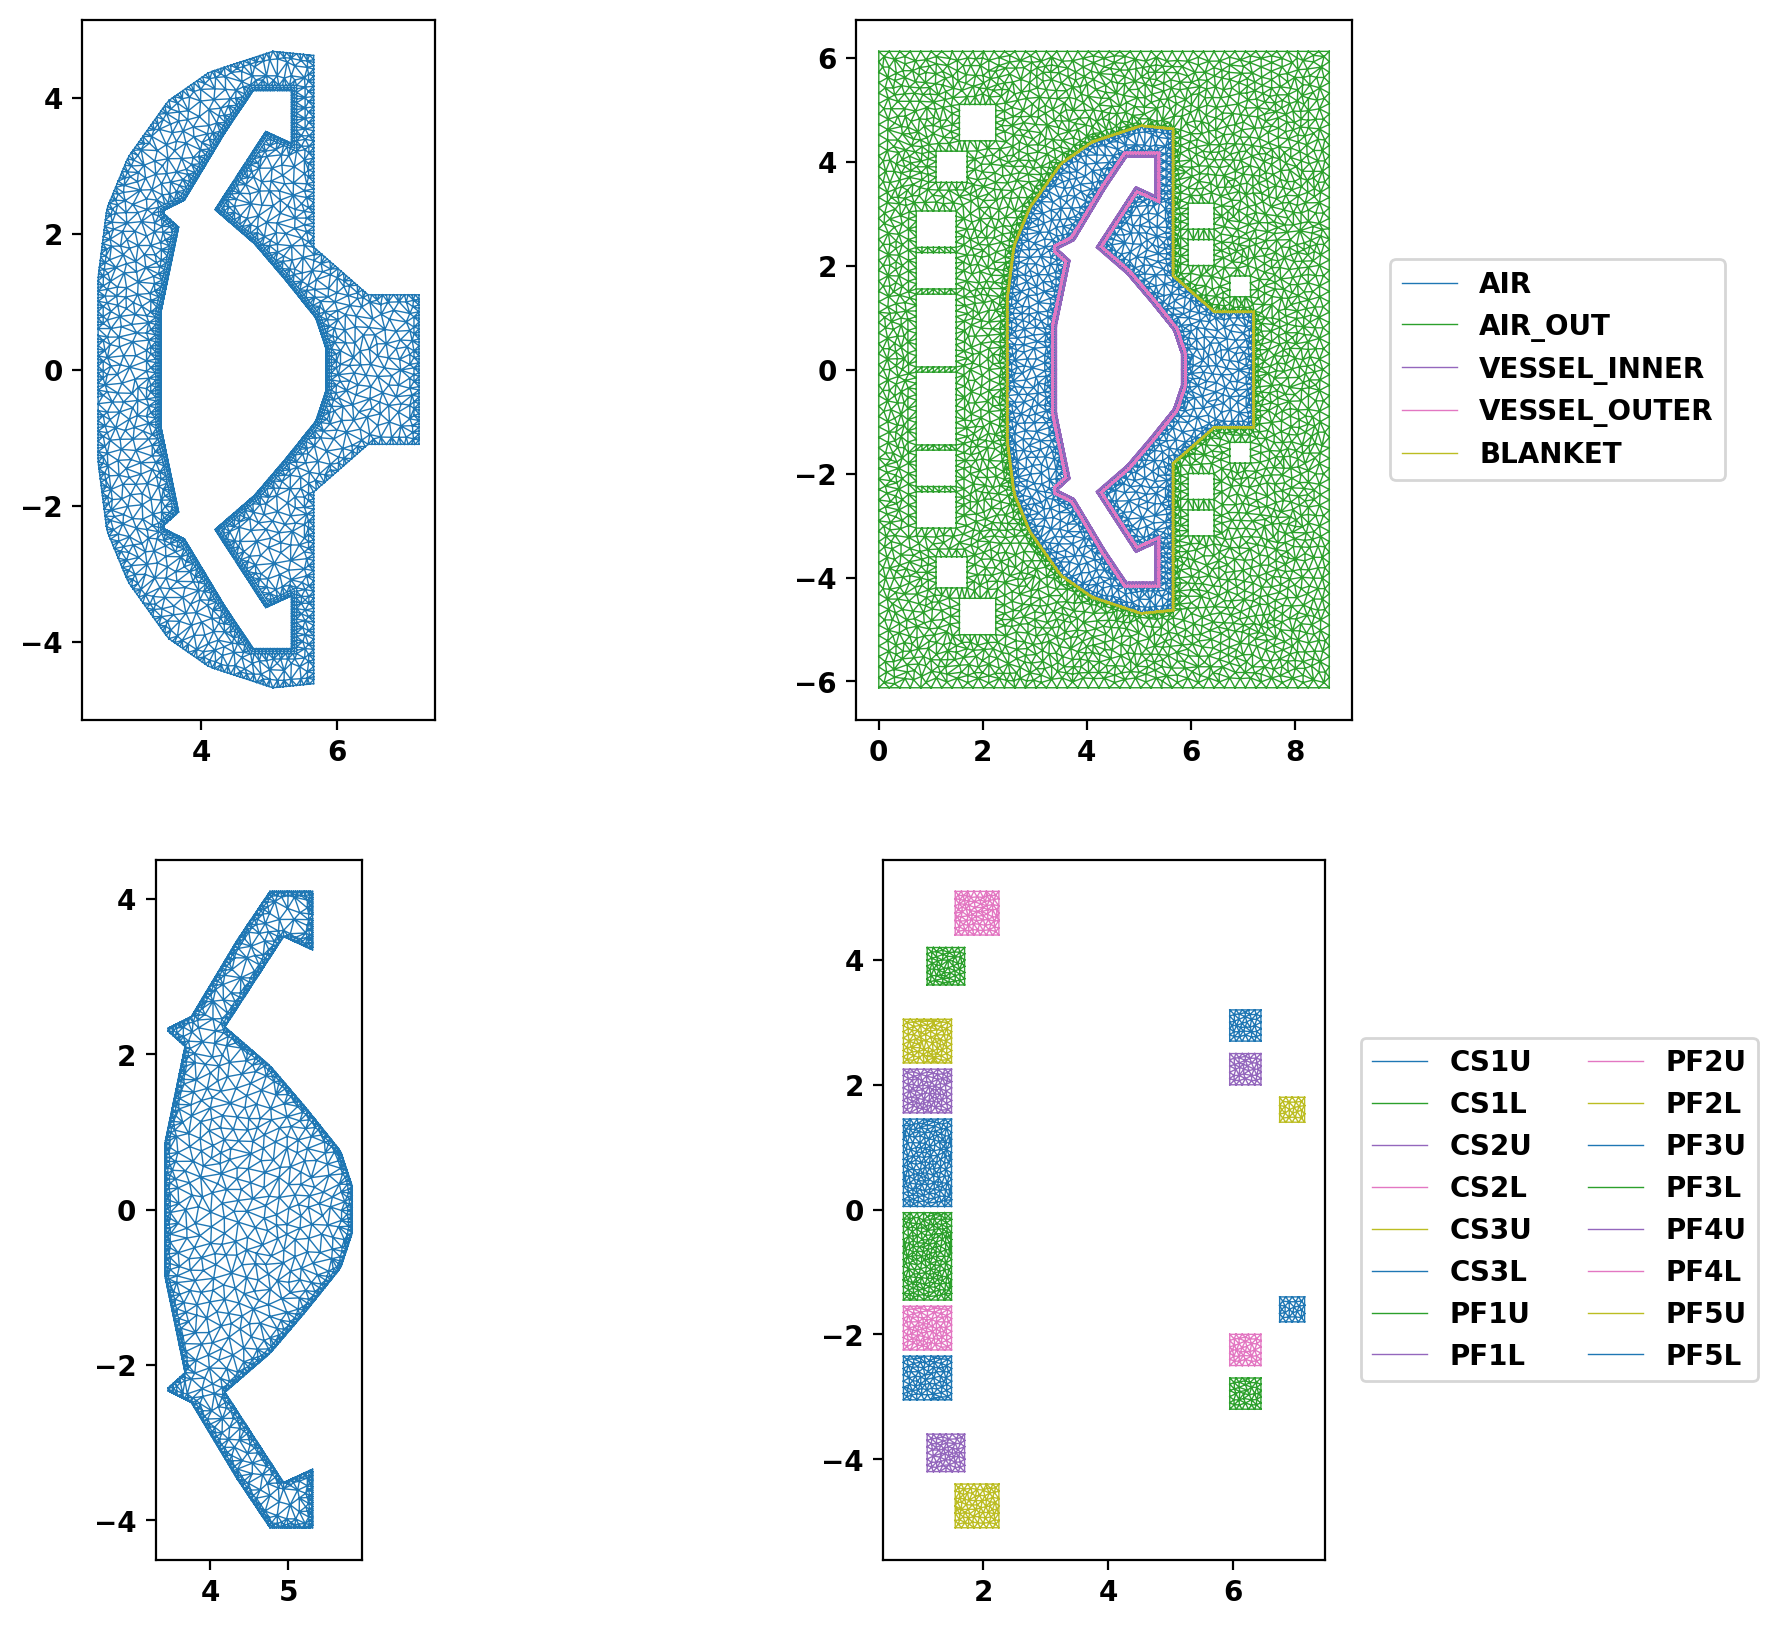

In [11]:
fig, ax = plt.subplots(2,2,figsize=(10,10))
ax[0,0].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==2,:],lw=0.5)  # plasma
ax[1,0].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==1,:],lw=0.5)  # air
for key, cond in cond_dict.items():
    ax[0,1].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==cond['reg_id'],:],lw=0.5,label=key)  # conductors
for key, coil in coil_dict.items():
    ax[1,1].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==coil['reg_id'],:],lw=0.5,label=key)  # coils
for ax_tmp in ax.flatten():
    ax_tmp.set_aspect('equal','box')
ax[0,1].legend(bbox_to_anchor=(1.05,0.5), loc='center left')
_ = ax[1,1].legend(bbox_to_anchor=(1.05,0.5), ncol=2, loc='center left')

plt.show()


AIR
AIR_OUT
VESSEL_INNER
VESSEL_OUTER
BLANKET


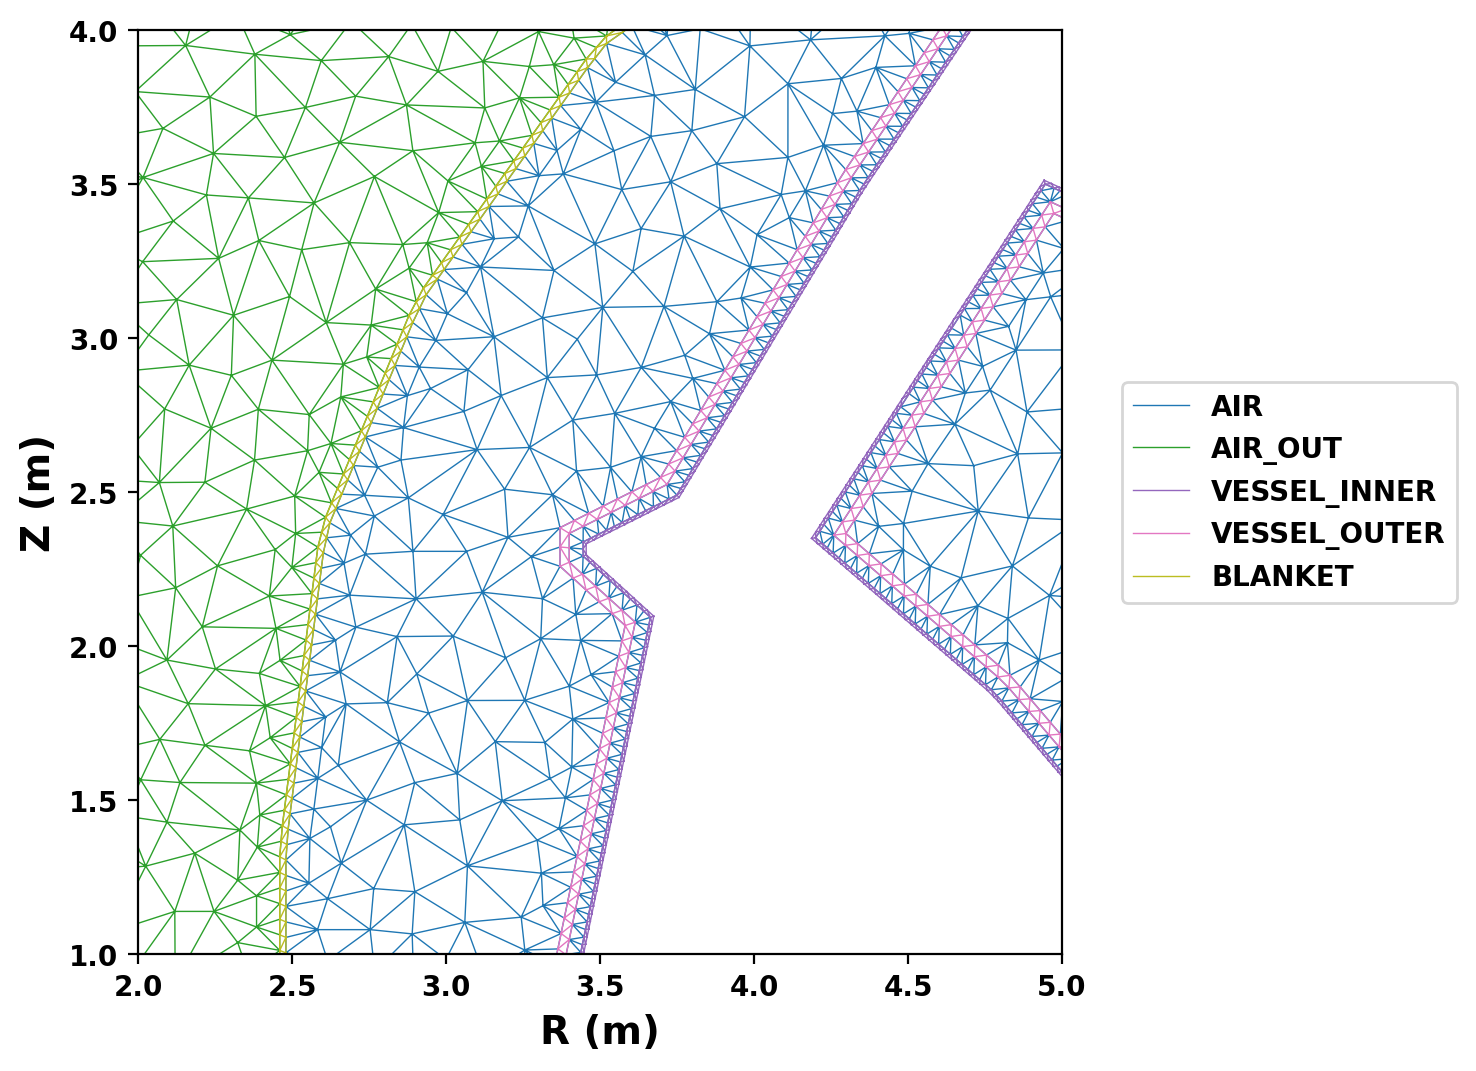

In [12]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

for key, cond in cond_dict.items():
    print(key)
    ax.triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==cond['reg_id'],:],lw=0.5,label=key)
for key, coil in coil_dict.items():
    ax.triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==coil['reg_id'],:],lw=0.5,color='k')
    
ax.set_aspect('equal','box')
ax.set_xlim(2,5)
ax.set_ylim(1,4)
ax.legend(bbox_to_anchor=(1.05,0.5), loc='center left')
ax.set_xlabel('R (m)', fontsize=14)
ax.set_ylabel('Z (m)', fontsize=14)

plt.show()

## Save mesh for later use

As generation of the mesh often takes comparable, or longer, time compare to runs in TokaMaker it is useful to separate generation of the mesh into a different script as demonstrated here. The method `save_gs_mesh` can be used to save the resulting information for later use. This is done using and an HDF5 file through the h5py library.

In [13]:
fname = ''
if include_FLIBE:
    fname += '_withFLIBE'
if include_shield:
    fname += '_withShield'

save_gs_mesh(mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict, f"arc_v3a_mesh{fname}.h5")